<a href="https://colab.research.google.com/github/rvs0514/logisticssqlpipeline/blob/main/logistics_sql_pipeline_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚛 Logistics SQL Data Pipeline
## Time-Based Cost Analysis · Pricing Model Optimisation · Gross Profit Alignment
---
| Module | Purpose |
|--------|---------|
| **0** — Setup & Database | SQLite schema + 12 months synthetic logistics data |
| **1** — Data Pipeline | SQL ingestion, validation, time-period slicing |
| **2** — Cost Analysis | Cost drivers, trends, variance by period & route |
| **3** — Revenue & Pricing Audit | Current pricing model vs actual cost coverage |
| **4** — Gross Profit Deep Dive | GP % by service, route, month vs targets |
| **5** — Pricing Optimiser | Adjust rates to close GP gaps — scenario output |
| **6** — Executive Dashboard | One-page summary of all key metrics |

> **All monetary values in GBP.

---
## ⚙️ Module 0 — Setup & Database Build


In [1]:
import sqlite3, random, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import datetime
import warnings
warnings.filterwarnings("ignore")

# ── Chart style ───────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor":  "#0D1117",
    "axes.facecolor":    "#161B22",
    "axes.edgecolor":    "#30363D",
    "axes.labelcolor":   "#C9D1D9",
    "axes.grid":         True,
    "grid.color":        "#21262D",
    "grid.alpha":        1.0,
    "xtick.color":       "#8B949E",
    "ytick.color":       "#8B949E",
    "text.color":        "#C9D1D9",
    "legend.facecolor":  "#161B22",
    "legend.edgecolor":  "#30363D",
    "font.size":         10,
})

TEAL = "#2DD4BF"; BLUE = "#60A5FA"; PURPLE = "#A78BFA"
AMBER = "#FBBF24"; GREEN = "#34D399"; RED = "#F87171"
GREY = "#6B7280"; ORANGE = "#FB923C"; NAVY = "#0D1117"
P = "\u00a3"  # pound sign

# ── Database setup ────────────────────────────────────────────────────────
DB_PATH = "/tmp/logistics_pipeline.db"
if os.path.exists(DB_PATH): os.remove(DB_PATH)
conn = sqlite3.connect(DB_PATH)
cur  = conn.cursor()

# ── Schema ────────────────────────────────────────────────────────────────
cur.executescript("""
CREATE TABLE routes (
    route_id        TEXT PRIMARY KEY,
    origin          TEXT NOT NULL,
    destination     TEXT NOT NULL,
    distance_km     REAL NOT NULL,
    avg_transit_hrs REAL NOT NULL,
    region          TEXT NOT NULL
);
CREATE TABLE pricing_model (
    service_type        TEXT PRIMARY KEY,
    base_rate_per_kg    REAL NOT NULL,
    fuel_surcharge_pct  REAL NOT NULL,
    handling_fee        REAL NOT NULL,
    min_charge          REAL NOT NULL,
    last_updated        TEXT NOT NULL
);
CREATE TABLE gp_targets (
    service_type  TEXT PRIMARY KEY,
    target_gp_pct REAL NOT NULL
);
CREATE TABLE shipments (
    shipment_id     TEXT PRIMARY KEY,
    ship_date       TEXT NOT NULL,
    route_id        TEXT NOT NULL,
    service_type    TEXT NOT NULL,
    weight_kg       REAL NOT NULL,
    volume_m3       REAL NOT NULL,
    transit_hrs_act REAL NOT NULL,
    transit_hrs_std REAL NOT NULL,
    delay_hrs       REAL NOT NULL,
    status          TEXT NOT NULL,
    FOREIGN KEY (route_id) REFERENCES routes(route_id)
);
CREATE TABLE cost_actuals (
    cost_id         INTEGER PRIMARY KEY AUTOINCREMENT,
    shipment_id     TEXT NOT NULL,
    ship_date       TEXT NOT NULL,
    fuel_cost       REAL NOT NULL,
    labour_cost     REAL NOT NULL,
    overhead_cost   REAL NOT NULL,
    handling_cost   REAL NOT NULL,
    delay_penalty   REAL NOT NULL,
    total_cost      REAL GENERATED ALWAYS AS
                    (fuel_cost+labour_cost+overhead_cost+handling_cost+delay_penalty)
                    STORED,
    FOREIGN KEY (shipment_id) REFERENCES shipments(shipment_id)
);
CREATE TABLE revenue (
    rev_id          INTEGER PRIMARY KEY AUTOINCREMENT,
    shipment_id     TEXT NOT NULL,
    ship_date       TEXT NOT NULL,
    base_revenue    REAL NOT NULL,
    fuel_surcharge  REAL NOT NULL,
    handling_rev    REAL NOT NULL,
    total_revenue   REAL GENERATED ALWAYS AS
                    (base_revenue+fuel_surcharge+handling_rev)
                    STORED,
    FOREIGN KEY (shipment_id) REFERENCES shipments(shipment_id)
);
""")
conn.commit()

# ── Seed data ─────────────────────────────────────────────────────────────
random.seed(42); np.random.seed(42)

routes_data = [
    ("RT-001","London","Manchester",  315,  4.5,"North"),
    ("RT-002","London","Birmingham",  190,  2.8,"Midlands"),
    ("RT-003","Manchester","Leeds",    65,  1.2,"North"),
    ("RT-004","Birmingham","Bristol", 145,  2.2,"South West"),
    ("RT-005","London","Bristol",     190,  2.9,"South West"),
    ("RT-006","Manchester","Glasgow", 345,  5.5,"Scotland"),
    ("RT-007","Leeds","Sheffield",     58,  1.0,"North"),
    ("RT-008","London","Edinburgh",   660, 10.0,"Scotland"),
    ("RT-009","Birmingham","Nottingham",80, 1.3,"Midlands"),
    ("RT-010","Bristol","Cardiff",     65,  1.2,"Wales"),
]
cur.executemany("INSERT INTO routes VALUES (?,?,?,?,?,?)", routes_data)

pricing_data = [
    ("Express",   0.045, 0.12, 18.0, 35.0, "2024-01-01"),
    ("Standard",  0.028, 0.10, 10.0, 20.0, "2024-01-01"),
    ("Economy",   0.018, 0.08,  6.0, 14.0, "2024-01-01"),
    ("Overnight", 0.072, 0.15, 25.0, 60.0, "2024-01-01"),
]
cur.executemany("INSERT INTO pricing_model VALUES (?,?,?,?,?,?)", pricing_data)

gp_targets_data = [
    ("Express", 0.38), ("Standard", 0.32),
    ("Economy", 0.25), ("Overnight", 0.42),
]
cur.executemany("INSERT INTO gp_targets VALUES (?,?)", gp_targets_data)

# ── Generate 14 months of shipments (Jan 2024 - Feb 2025) ─────────────────
service_types = ["Express","Standard","Economy","Overnight"]
service_mix   = [0.25, 0.42, 0.22, 0.11]

cost_structure = {
    "Express":   (0.020, 0.012, 0.006,  8.0, 3.5),
    "Standard":  (0.016, 0.009, 0.005,  5.5, 2.0),
    "Economy":   (0.012, 0.007, 0.004,  3.5, 1.2),
    "Overnight": (0.028, 0.018, 0.009, 12.0, 5.0),
}

def fuel_multiplier(d):
    if datetime.date(2024,7,1) <= d <= datetime.date(2024,9,30):  return 1.28
    if datetime.date(2024,10,1) <= d <= datetime.date(2024,12,31): return 1.12
    return 1.0

start_date = datetime.date(2024,1,1)
end_date   = datetime.date(2025,2,28)
shipment_rows, cost_rows, revenue_rows = [], [], []
ship_counter = 0
pm_dict = {r[0]: r for r in pricing_data}

for day_offset in range((end_date - start_date).days + 1):
    cur_date = start_date + datetime.timedelta(days=day_offset)
    if cur_date.weekday() >= 6: continue
    fm = fuel_multiplier(cur_date)
    date_str = cur_date.isoformat()
    for _ in range(random.randint(6,14)):
        ship_counter += 1
        sid    = f"SHP-{ship_counter:05d}"
        rt     = random.choice(routes_data)
        dist   = rt[3]; std_hrs = rt[4]
        svc    = random.choices(service_types, weights=service_mix)[0]
        weight = round(max(1.0, min(random.lognormvariate(4.0,0.8), 2500.0)), 1)
        volume = round(weight * random.uniform(0.001, 0.003), 3)
        d_flag = np.random.choice([0,1], p=[0.82,0.18])
        delay  = round(d_flag * random.uniform(0.5,6.0), 2)
        act    = round(std_hrs * random.uniform(0.92,1.08) + delay, 2)
        status = "Delayed" if delay > 0 else random.choices(["Delivered","Damaged"],[0.97,0.03])[0]
        shipment_rows.append((sid,date_str,rt[0],svc,weight,volume,act,std_hrs,delay,status))
        fc_r,lc_r,oc_r,h_flat,dp_rate = cost_structure[svc]
        fuel_c   = round(fc_r*weight*dist/100*fm*random.uniform(0.9,1.1),2)
        lab_c    = round(lc_r*weight*act*random.uniform(0.9,1.1),2)
        oh_c     = round(oc_r*weight*random.uniform(0.85,1.15),2)
        hand_c   = round(h_flat*random.uniform(0.95,1.05),2)
        pen      = round(delay*dp_rate,2)
        cost_rows.append((sid,date_str,fuel_c,lab_c,oh_c,hand_c,pen))
        pm = pm_dict[svc]
        b_rev = round(max(pm[4], pm[1]*weight),2)
        f_sur = round(b_rev*pm[2],2)
        h_rev = round(pm[3],2)
        revenue_rows.append((sid,date_str,b_rev,f_sur,h_rev))

cur.executemany("INSERT INTO shipments VALUES (?,?,?,?,?,?,?,?,?,?)", shipment_rows)
cur.executemany(
    "INSERT INTO cost_actuals(shipment_id,ship_date,fuel_cost,labour_cost,"
    "overhead_cost,handling_cost,delay_penalty) VALUES (?,?,?,?,?,?,?)", cost_rows)
cur.executemany(
    "INSERT INTO revenue(shipment_id,ship_date,base_revenue,fuel_surcharge,handling_rev)"
    " VALUES (?,?,?,?,?)", revenue_rows)
conn.commit()

print(f"Schema + data loaded: {ship_counter:,} shipments | "
      f"{len(cost_rows):,} cost records | {len(revenue_rows):,} revenue records")
print(f"Date range: 2024-01-01 to 2025-02-28  |  10 routes  |  4 service types")


Schema + data loaded: 3,601 shipments | 3,601 cost records | 3,601 revenue records
Date range: 2024-01-01 to 2025-02-28  |  10 routes  |  4 service types


---
## 🔄 Module 1 — SQL Data Pipeline & Validation


TABLE ROW COUNTS
  routes                    10 rows
  pricing_model              4 rows
  gp_targets                 4 rows
  shipments              3,601 rows
  cost_actuals           3,601 rows
  revenue                3,601 rows

DATE RANGE & VOLUME
  earliest     latest  working_days  total_shipments  avg_daily
2024-01-01 2025-02-28           365             3601        9.9

SERVICE MIX & PERFORMANCE
service_type  shipments  mix_pct  avg_weight_kg  avg_transit_hrs  avg_delay_hrs  delayed  damaged
    Standard       1483     41.2           77.8             3.80           0.54      260       32
     Express        949     26.4           73.4             3.86           0.57      169       24
     Economy        795     22.1           73.7             3.94           0.63      146       13
   Overnight        374     10.4           81.6             4.19           0.60       62        6

MONTHLY SHIPMENT PIPELINE
  month  shipments  total_kg  delayed  delay_pct
2024-01        253   2048

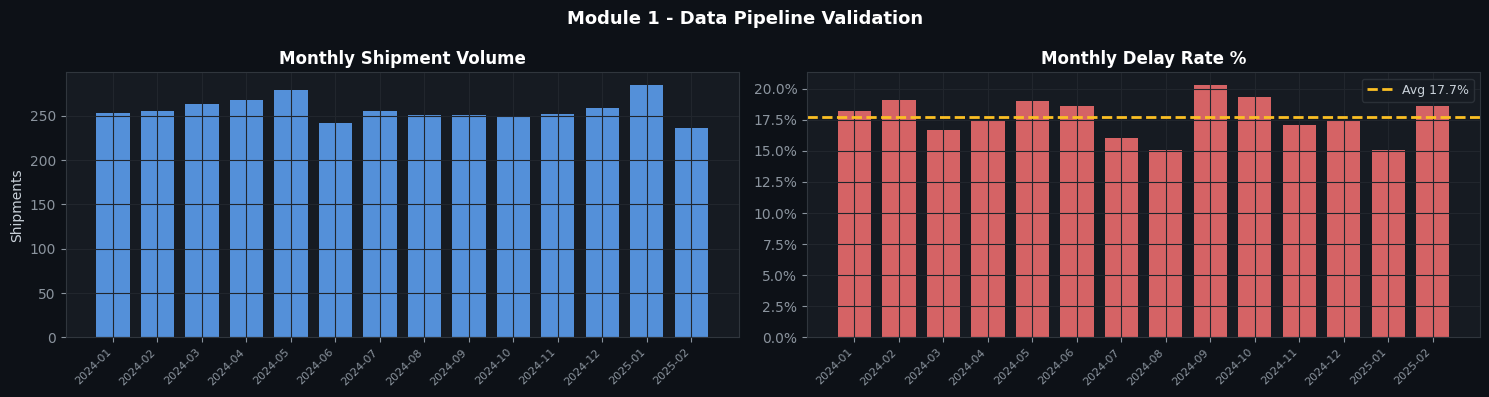

In [2]:
# Pipeline helper
def sql(query, params=None):
    """Execute SQL and return a pandas DataFrame."""
    return pd.read_sql_query(query, conn, params=params)

# ── Table row counts ──────────────────────────────────────────────────────
print("=" * 60)
print("TABLE ROW COUNTS")
print("=" * 60)
for tbl in ["routes","pricing_model","gp_targets","shipments","cost_actuals","revenue"]:
    n = sql(f"SELECT COUNT(*) AS n FROM {tbl}").iloc[0,0]
    print(f"  {tbl:<20}  {n:>6,} rows")

# ── Date range & volume ───────────────────────────────────────────────────
summary = sql("""
    SELECT MIN(ship_date) AS earliest, MAX(ship_date) AS latest,
           COUNT(DISTINCT ship_date) AS working_days,
           COUNT(*) AS total_shipments,
           ROUND(COUNT(*)*1.0/COUNT(DISTINCT ship_date),1) AS avg_daily
    FROM shipments
""")
print("\n" + "=" * 60)
print("DATE RANGE & VOLUME")
print("=" * 60)
print(summary.to_string(index=False))

# ── Service mix ───────────────────────────────────────────────────────────
mix = sql("""
    SELECT service_type,
           COUNT(*) AS shipments,
           ROUND(COUNT(*)*100.0/SUM(COUNT(*)) OVER(),1) AS mix_pct,
           ROUND(AVG(weight_kg),1)          AS avg_weight_kg,
           ROUND(AVG(transit_hrs_act),2)    AS avg_transit_hrs,
           ROUND(AVG(delay_hrs),2)          AS avg_delay_hrs,
           COUNT(CASE WHEN status="Delayed" THEN 1 END) AS delayed,
           COUNT(CASE WHEN status="Damaged" THEN 1 END) AS damaged
    FROM shipments
    GROUP BY service_type
    ORDER BY shipments DESC
""")
print("\n" + "=" * 60)
print("SERVICE MIX & PERFORMANCE")
print("=" * 60)
print(mix.to_string(index=False))

# ── Monthly volume pipeline ───────────────────────────────────────────────
monthly_vol = sql("""
    SELECT STRFTIME("%Y-%m", ship_date) AS month,
           COUNT(*) AS shipments,
           ROUND(SUM(weight_kg),0) AS total_kg,
           COUNT(CASE WHEN status="Delayed" THEN 1 END) AS delayed,
           ROUND(COUNT(CASE WHEN status="Delayed" THEN 1 END)*100.0/COUNT(*),1) AS delay_pct
    FROM shipments
    GROUP BY month ORDER BY month
""")
print("\n" + "=" * 60)
print("MONTHLY SHIPMENT PIPELINE")
print("=" * 60)
print(monthly_vol.to_string(index=False))

# ── Volume chart ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 4))
fig.patch.set_facecolor(NAVY)
fig.suptitle("Module 1 - Data Pipeline Validation", color="white",
             fontsize=13, fontweight="bold")
months_x = monthly_vol["month"].tolist()
xi = range(len(months_x))
axes[0].bar(xi, monthly_vol["shipments"], color=BLUE, alpha=0.85, width=0.75)
axes[0].set_xticks(xi)
axes[0].set_xticklabels(months_x, rotation=45, ha="right", fontsize=8)
axes[0].set_title("Monthly Shipment Volume", color="white", fontweight="bold")
axes[0].set_ylabel("Shipments")
axes[1].bar(xi, monthly_vol["delay_pct"], color=RED, alpha=0.85, width=0.75)
axes[1].axhline(monthly_vol["delay_pct"].mean(), color=AMBER, lw=2,
                linestyle="--", label=f'Avg {monthly_vol["delay_pct"].mean():.1f}%')
axes[1].set_xticks(xi)
axes[1].set_xticklabels(months_x, rotation=45, ha="right", fontsize=8)
axes[1].set_title("Monthly Delay Rate %", color="white", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.1f}%"))
axes[1].legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## 📉 Module 2 — Time-Based Cost Analysis


QUARTERLY COST BREAKDOWN
quarter    fuel  labour  overhead  handling  delay_penalty  total_cost  fuel_pct  delay_pct
Q1-2024 2482.04 2604.30    339.32   5034.05        1097.86    11557.57      21.5        9.5
Q2-2024 2108.40 2242.69    321.82   4955.92        1191.42    10820.25      19.5       11.0
Q3-2024 2589.66 2123.97    306.27   4889.86        1003.39    10913.15      23.7        9.2
Q4-2024 2554.26 2482.82    325.72   4827.79        1117.32    11307.91      22.6        9.9

COST PER KG BY ROUTE (highest first)
                   route  distance_km  shipments  avg_total_cost  avg_fuel  avg_delay_pen  cost_per_kg
     London to Edinburgh        660.0        380           27.75      9.93           1.92       0.4754
   Manchester to Glasgow        345.0        364           16.58      4.52           1.14       0.3113
    London to Manchester        315.0        369           17.38      4.93           1.21       0.2949
    London to Birmingham        190.0        363           13.17 

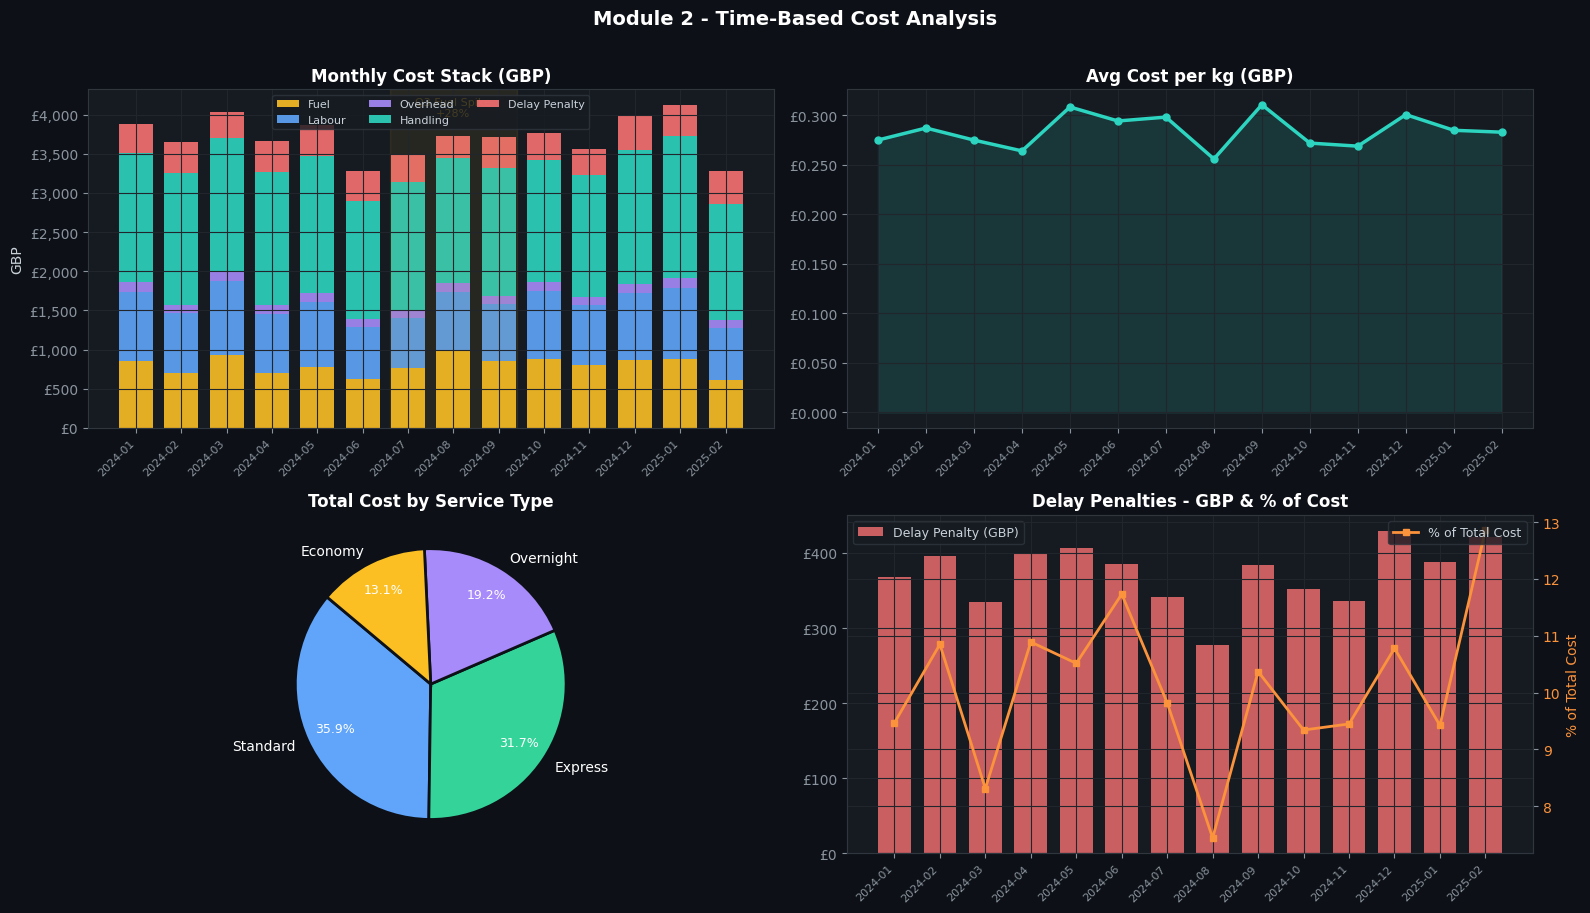

In [3]:
# ── Monthly cost aggregation ──────────────────────────────────────────────
monthly_agg = sql("""
    SELECT STRFTIME("%Y-%m", c.ship_date) AS month,
           ROUND(SUM(c.fuel_cost),2)      AS fuel,
           ROUND(SUM(c.labour_cost),2)    AS labour,
           ROUND(SUM(c.overhead_cost),2)  AS overhead,
           ROUND(SUM(c.handling_cost),2)  AS handling,
           ROUND(SUM(c.delay_penalty),2)  AS delay_penalty,
           ROUND(SUM(c.total_cost),2)     AS total_cost,
           ROUND(AVG(c.total_cost/NULLIF(s.weight_kg,0)),4) AS avg_cost_per_kg
    FROM cost_actuals c
    JOIN shipments s ON c.shipment_id = s.shipment_id
    GROUP BY month ORDER BY month
""")

# ── Quarterly cost breakdown ──────────────────────────────────────────────
qtr_costs = sql("""
    SELECT
        CASE
            WHEN STRFTIME("%m",c.ship_date) IN ("01","02","03") THEN "Q1-2024"
            WHEN STRFTIME("%m",c.ship_date) IN ("04","05","06") THEN "Q2-2024"
            WHEN STRFTIME("%m",c.ship_date) IN ("07","08","09") THEN "Q3-2024"
            WHEN STRFTIME("%m",c.ship_date) IN ("10","11","12") THEN "Q4-2024"
            ELSE "Q1-2025"
        END AS quarter,
        ROUND(SUM(c.fuel_cost),2)       AS fuel,
        ROUND(SUM(c.labour_cost),2)     AS labour,
        ROUND(SUM(c.overhead_cost),2)   AS overhead,
        ROUND(SUM(c.handling_cost),2)   AS handling,
        ROUND(SUM(c.delay_penalty),2)   AS delay_penalty,
        ROUND(SUM(c.total_cost),2)      AS total_cost,
        ROUND(SUM(c.fuel_cost)*100.0/SUM(c.total_cost),1) AS fuel_pct,
        ROUND(SUM(c.delay_penalty)*100.0/SUM(c.total_cost),1) AS delay_pct
    FROM cost_actuals c
    JOIN shipments s ON c.shipment_id = s.shipment_id
    WHERE c.ship_date < "2025-01-01"
    GROUP BY quarter ORDER BY quarter
""")
print("=" * 72)
print("QUARTERLY COST BREAKDOWN")
print("=" * 72)
print(qtr_costs.to_string(index=False))

# ── Cost per kg by route ──────────────────────────────────────────────────
route_costs = sql("""
    SELECT r.origin || " to " || r.destination AS route,
           r.distance_km,
           COUNT(*) AS shipments,
           ROUND(AVG(c.total_cost),2) AS avg_total_cost,
           ROUND(AVG(c.fuel_cost),2)  AS avg_fuel,
           ROUND(AVG(c.delay_penalty),2) AS avg_delay_pen,
           ROUND(AVG(c.total_cost/NULLIF(s.weight_kg,0)),4) AS cost_per_kg
    FROM cost_actuals c
    JOIN shipments s ON c.shipment_id = s.shipment_id
    JOIN routes    r ON s.route_id    = r.route_id
    GROUP BY r.route_id ORDER BY cost_per_kg DESC
""")
print("\n" + "=" * 72)
print("COST PER KG BY ROUTE (highest first)")
print("=" * 72)
print(route_costs.to_string(index=False))

# ── Charts ────────────────────────────────────────────────────────────────
months_l = monthly_agg["month"].tolist()
xi = range(len(months_l))

fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.patch.set_facecolor(NAVY)
fig.suptitle("Module 2 - Time-Based Cost Analysis", color="white",
             fontsize=14, fontweight="bold", y=1.01)

# Stacked cost bar
drivers  = ["fuel","labour","overhead","handling","delay_penalty"]
dcolors  = [AMBER, BLUE, PURPLE, TEAL, RED]
dlabels  = ["Fuel","Labour","Overhead","Handling","Delay Penalty"]
bottoms  = np.zeros(len(months_l))
for drv, col, lbl in zip(drivers, dcolors, dlabels):
    vals = monthly_agg[drv].values
    axes[0,0].bar(xi, vals, bottom=bottoms, color=col, label=lbl,
                  alpha=0.9, width=0.75, edgecolor="none")
    bottoms += vals
axes[0,0].set_xticks(xi)
axes[0,0].set_xticklabels(months_l, rotation=45, ha="right", fontsize=8)
axes[0,0].set_title("Monthly Cost Stack (GBP)", color="white", fontweight="bold")
axes[0,0].set_ylabel("GBP")
axes[0,0].legend(fontsize=8, ncol=3)
axes[0,0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{P}{v:,.0f}"))
q3_start = months_l.index("2024-07")
axes[0,0].axvspan(q3_start-0.4, q3_start+2.4, color=AMBER, alpha=0.08)
axes[0,0].text(q3_start+1, axes[0,0].get_ylim()[1]*0.92,
               "Q3 Fuel Spike\n+28%", color=AMBER, fontsize=8, ha="center")

# Cost per kg trend
axes[0,1].plot(xi, monthly_agg["avg_cost_per_kg"], color=TEAL, lw=2.5,
               marker="o", markersize=5)
axes[0,1].fill_between(xi, monthly_agg["avg_cost_per_kg"], alpha=0.15, color=TEAL)
axes[0,1].set_xticks(xi)
axes[0,1].set_xticklabels(months_l, rotation=45, ha="right", fontsize=8)
axes[0,1].set_title("Avg Cost per kg (GBP)", color="white", fontweight="bold")
axes[0,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{P}{v:.3f}"))

# Cost split by service type (pie)
svc_costs = sql("""
    SELECT s.service_type, ROUND(SUM(c.total_cost),2) AS total
    FROM cost_actuals c JOIN shipments s ON c.shipment_id=s.shipment_id
    GROUP BY s.service_type ORDER BY total DESC
""")
pie_colors = [BLUE, GREEN, PURPLE, AMBER]
wedges,texts,autotexts = axes[1,0].pie(
    svc_costs["total"], labels=svc_costs["service_type"],
    colors=pie_colors, autopct="%1.1f%%", startangle=140,
    pctdistance=0.78, wedgeprops={"edgecolor":NAVY,"linewidth":2})
for t in texts:     t.set_color("white"); t.set_fontsize(10)
for a in autotexts: a.set_color("white"); a.set_fontsize(9)
axes[1,0].set_title("Total Cost by Service Type", color="white", fontweight="bold")

# Delay penalty trend
delay_vals = monthly_agg["delay_penalty"].values
delay_pct  = delay_vals / monthly_agg["total_cost"].values * 100
axes[1,1].bar(xi, delay_vals, color=RED, alpha=0.8, width=0.72, label="Delay Penalty (GBP)")
ax2r = axes[1,1].twinx()
ax2r.plot(xi, delay_pct, color=ORANGE, lw=2, marker="s", markersize=5,
          label="% of Total Cost")
ax2r.set_ylabel("% of Total Cost", color=ORANGE)
ax2r.tick_params(axis="y", labelcolor=ORANGE)
axes[1,1].set_xticks(xi)
axes[1,1].set_xticklabels(months_l, rotation=45, ha="right", fontsize=8)
axes[1,1].set_title("Delay Penalties - GBP & % of Cost", color="white", fontweight="bold")
axes[1,1].legend(loc="upper left", fontsize=9)
ax2r.legend(loc="upper right", fontsize=9)
axes[1,1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{P}{v:,.0f}"))
plt.tight_layout()
plt.show()


---
## 💷 Module 3 — Revenue & Pricing Audit


MONTHLY P&L - REVENUE vs COST vs GROSS PROFIT
  month  revenue  total_cost  gross_profit  gp_pct  base_rev  fuel_surcharge  handling_rev
2024-01 11126.16     3881.09       7245.07   65.12    6967.0          815.16        3344.0
2024-02 11275.44     3644.68       7630.76   67.68    7083.0          838.44        3354.0
2024-03 11446.96     4031.80       7415.16   64.78    7167.0          831.96        3448.0
2024-04 11289.76     3663.81       7625.95   67.55    7092.0          821.76        3376.0
2024-05 11581.20     3872.60       7708.60   66.56    7280.0          840.20        3461.0
2024-06 10133.44     3283.84       6849.60   67.59    6363.0          733.44        3037.0
2024-07 11091.04     3478.35       7612.69   68.64    6968.0          817.04        3306.0
2024-08 10618.88     3727.08       6891.80   64.90    6666.0          772.88        3180.0
2024-09 11034.96     3707.72       7327.24   66.40    6917.0          811.96        3306.0
2024-10 10343.12     3766.39       6576.73  

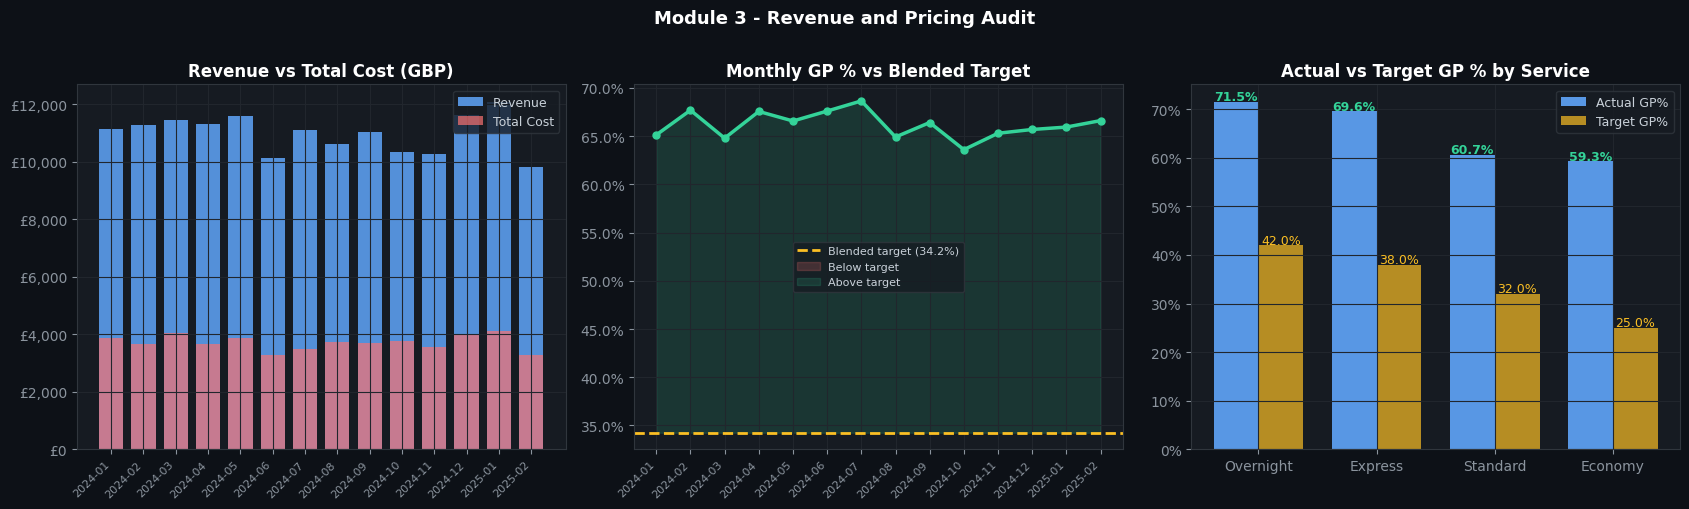

In [4]:
# ── Monthly P&L ──────────────────────────────────────────────────────────
monthly_pnl = sql("""
    SELECT STRFTIME("%Y-%m", r.ship_date) AS month,
           ROUND(SUM(r.total_revenue),2)  AS revenue,
           ROUND(SUM(c.total_cost),2)     AS total_cost,
           ROUND(SUM(r.total_revenue)-SUM(c.total_cost),2) AS gross_profit,
           ROUND((SUM(r.total_revenue)-SUM(c.total_cost))*100.0
                 /NULLIF(SUM(r.total_revenue),0),2) AS gp_pct,
           ROUND(SUM(r.base_revenue),2)   AS base_rev,
           ROUND(SUM(r.fuel_surcharge),2) AS fuel_surcharge,
           ROUND(SUM(r.handling_rev),2)   AS handling_rev
    FROM revenue r
    JOIN cost_actuals c ON r.shipment_id = c.shipment_id
    GROUP BY month ORDER BY month
""")
print("=" * 78)
print("MONTHLY P&L - REVENUE vs COST vs GROSS PROFIT")
print("=" * 78)
print(monthly_pnl.to_string(index=False))

# ── Pricing adequacy by service type ─────────────────────────────────────
svc_pnl = sql("""
    SELECT s.service_type,
           p.base_rate_per_kg, p.fuel_surcharge_pct, p.handling_fee, p.min_charge,
           COUNT(*) AS shipments,
           ROUND(AVG(r.total_revenue),2) AS avg_revenue,
           ROUND(AVG(c.total_cost),2)    AS avg_cost,
           ROUND(AVG(r.total_revenue)-AVG(c.total_cost),2) AS avg_gp,
           ROUND((AVG(r.total_revenue)-AVG(c.total_cost))*100.0
                 /AVG(r.total_revenue),2) AS actual_gp_pct,
           t.target_gp_pct*100 AS target_gp_pct,
           ROUND(((AVG(r.total_revenue)-AVG(c.total_cost))*100.0/AVG(r.total_revenue))
                 - t.target_gp_pct*100, 2) AS gp_gap_ppts
    FROM shipments s
    JOIN revenue      r ON s.shipment_id = r.shipment_id
    JOIN cost_actuals c ON s.shipment_id = c.shipment_id
    JOIN pricing_model p ON s.service_type = p.service_type
    JOIN gp_targets    t ON s.service_type = t.service_type
    GROUP BY s.service_type ORDER BY actual_gp_pct DESC
""")
print("\n" + "=" * 78)
print("PRICING ADEQUACY vs GP TARGETS")
print("=" * 78)
print(svc_pnl[["service_type","base_rate_per_kg","avg_revenue","avg_cost",
               "actual_gp_pct","target_gp_pct","gp_gap_ppts"]].to_string(index=False))
print()
for _, row in svc_pnl.iterrows():
    mark = "OK" if row["gp_gap_ppts"] >= 0 else "BELOW TARGET"
    print(f"  [{mark:<12}]  {row['service_type']:<12}  "
          f"Actual: {row['actual_gp_pct']:.1f}%  Target: {row['target_gp_pct']:.1f}%  "
          f"Gap: {row['gp_gap_ppts']:+.1f}ppts")

# ── Charts ────────────────────────────────────────────────────────────────
months_l = monthly_pnl["month"].tolist()
xi = range(len(months_l))
overall_target = svc_pnl["target_gp_pct"].mean()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(NAVY)
fig.suptitle("Module 3 - Revenue and Pricing Audit", color="white",
             fontsize=13, fontweight="bold", y=1.01)

axes[0].bar(xi, monthly_pnl["revenue"],    color=BLUE, alpha=0.85, label="Revenue", width=0.75)
axes[0].bar(xi, monthly_pnl["total_cost"], color=RED,  alpha=0.70, label="Total Cost", width=0.75)
axes[0].set_xticks(xi)
axes[0].set_xticklabels(months_l, rotation=45, ha="right", fontsize=8)
axes[0].set_title("Revenue vs Total Cost (GBP)", color="white", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{P}{v:,.0f}"))

axes[1].plot(xi, monthly_pnl["gp_pct"], color=GREEN, lw=2.5, marker="o", markersize=5)
axes[1].axhline(overall_target, color=AMBER, lw=2, linestyle="--",
                label=f"Blended target ({overall_target:.1f}%)")
axes[1].fill_between(xi, monthly_pnl["gp_pct"], overall_target,
                     where=(monthly_pnl["gp_pct"] < overall_target),
                     color=RED, alpha=0.2, label="Below target")
axes[1].fill_between(xi, monthly_pnl["gp_pct"], overall_target,
                     where=(monthly_pnl["gp_pct"] >= overall_target),
                     color=GREEN, alpha=0.15, label="Above target")
axes[1].set_xticks(xi)
axes[1].set_xticklabels(months_l, rotation=45, ha="right", fontsize=8)
axes[1].set_title("Monthly GP % vs Blended Target", color="white", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.1f}%"))
axes[1].legend(fontsize=8)

svcs = svc_pnl["service_type"].tolist()
xsvc = np.arange(len(svcs)); w = 0.38
axes[2].bar(xsvc-w/2, svc_pnl["actual_gp_pct"], w, color=BLUE,  alpha=0.9, label="Actual GP%")
axes[2].bar(xsvc+w/2, svc_pnl["target_gp_pct"], w, color=AMBER, alpha=0.7, label="Target GP%")
for i,(act,tgt) in enumerate(zip(svc_pnl["actual_gp_pct"],svc_pnl["target_gp_pct"])):
    col = GREEN if act >= tgt else RED
    axes[2].text(xsvc[i]-w/2, act+0.3, f"{act:.1f}%", ha="center", fontsize=9, color=col, fontweight="bold")
    axes[2].text(xsvc[i]+w/2, tgt+0.3, f"{tgt:.1f}%", ha="center", fontsize=9, color=AMBER)
axes[2].set_xticks(xsvc)
axes[2].set_xticklabels(svcs, fontsize=10)
axes[2].set_title("Actual vs Target GP % by Service", color="white", fontweight="bold")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## 📊 Module 4 — Gross Profit Deep Dive


GP % BY ROUTE & SERVICE TYPE (worst first)
                   route service_type  shipments  revenue    cost  gross_profit  gp_pct  target_pct
     London to Edinburgh     Standard        156  4992.00 3919.03       1072.97   21.49        32.0
     London to Edinburgh      Economy         75  1584.00 1140.81        443.19   27.98        25.0
     London to Edinburgh      Express         95  5434.00 3237.75       2196.25   40.42        38.0
    London to Manchester      Economy         83  1752.96  985.86        767.10   43.76        25.0
   Manchester to Glasgow      Economy         91  1921.92  931.70        990.22   51.52        25.0
   Manchester to Glasgow     Standard        145  4640.00 2229.40       2410.60   51.95        32.0
    London to Manchester     Standard        141  4512.00 2127.68       2384.32   52.84        32.0
     London to Edinburgh    Overnight         54  5076.00 2246.28       2829.72   55.75        42.0
   Birmingham to Bristol      Economy         79  1668.48

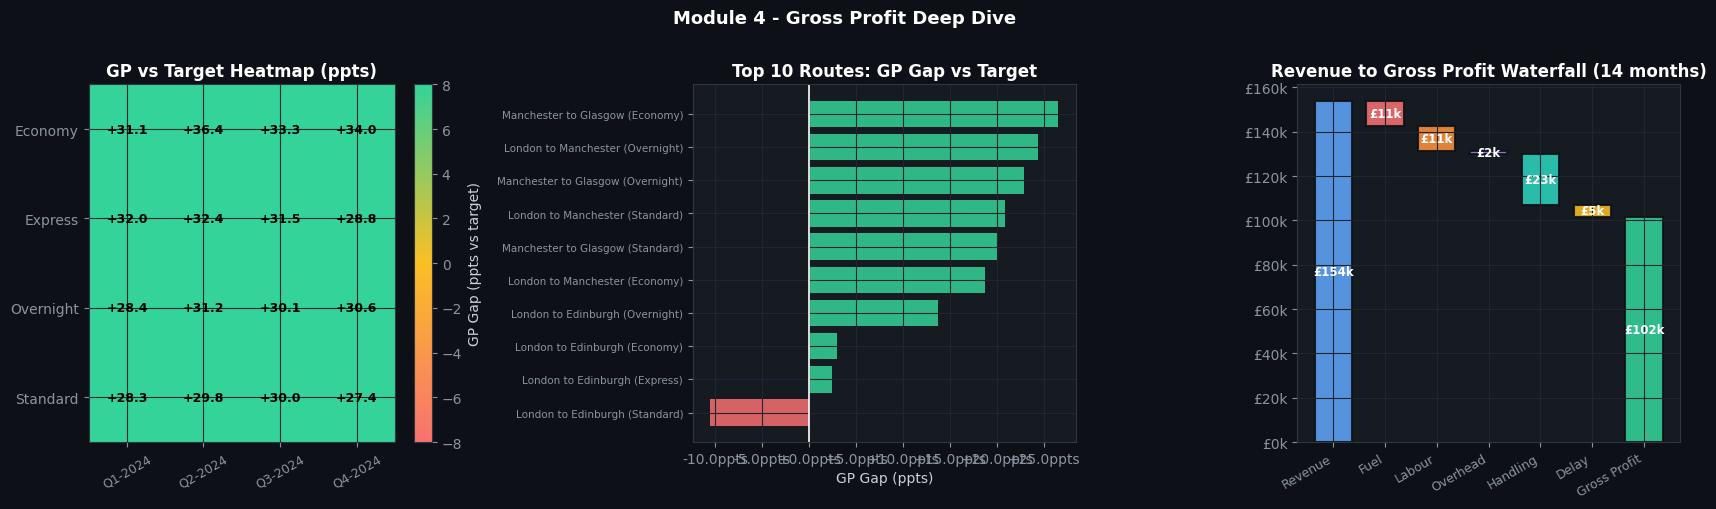

In [5]:
# ── GP by route ──────────────────────────────────────────────────────────
route_gp = sql("""
    SELECT ro.origin || " to " || ro.destination AS route,
           ro.distance_km, s.service_type,
           COUNT(*) AS shipments,
           ROUND(SUM(rv.total_revenue),2) AS revenue,
           ROUND(SUM(ca.total_cost),2)    AS cost,
           ROUND(SUM(rv.total_revenue)-SUM(ca.total_cost),2) AS gross_profit,
           ROUND((SUM(rv.total_revenue)-SUM(ca.total_cost))*100.0
                 /NULLIF(SUM(rv.total_revenue),0),2) AS gp_pct,
           t.target_gp_pct*100 AS target_pct
    FROM shipments s
    JOIN revenue      rv ON s.shipment_id = rv.shipment_id
    JOIN cost_actuals ca ON s.shipment_id = ca.shipment_id
    JOIN routes        ro ON s.route_id   = ro.route_id
    JOIN gp_targets    t  ON s.service_type = t.service_type
    GROUP BY ro.route_id, s.service_type
    ORDER BY gp_pct ASC
""")
print("=" * 80)
print("GP % BY ROUTE & SERVICE TYPE (worst first)")
print("=" * 80)
print(route_gp[["route","service_type","shipments","revenue","cost",
                 "gross_profit","gp_pct","target_pct"]].to_string(index=False))

# ── Quarterly GP heatmap data ─────────────────────────────────────────────
qtr_gp = sql("""
    SELECT
        CASE
            WHEN STRFTIME("%m",rv.ship_date) IN ("01","02","03") THEN "Q1-2024"
            WHEN STRFTIME("%m",rv.ship_date) IN ("04","05","06") THEN "Q2-2024"
            WHEN STRFTIME("%m",rv.ship_date) IN ("07","08","09") THEN "Q3-2024"
            WHEN STRFTIME("%m",rv.ship_date) IN ("10","11","12") THEN "Q4-2024"
            ELSE "Q1-2025"
        END AS quarter,
        s.service_type,
        ROUND((SUM(rv.total_revenue)-SUM(ca.total_cost))*100.0
              /NULLIF(SUM(rv.total_revenue),0),2) AS gp_pct,
        t.target_gp_pct*100 AS target_pct
    FROM shipments s
    JOIN revenue      rv ON s.shipment_id = rv.shipment_id
    JOIN cost_actuals ca ON s.shipment_id = ca.shipment_id
    JOIN gp_targets    t ON s.service_type = t.service_type
    WHERE rv.ship_date < "2025-01-01"
    GROUP BY quarter, s.service_type
    ORDER BY quarter, s.service_type
""")
pivot_qtr = qtr_gp.pivot(index="quarter", columns="service_type", values="gp_pct")
pivot_tgt = qtr_gp.pivot(index="quarter", columns="service_type", values="target_pct")
diff_arr  = pivot_qtr.values - pivot_tgt.values

# ── Charts ────────────────────────────────────────────────────────────────
from matplotlib.colors import LinearSegmentedColormap

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(NAVY)
fig.suptitle("Module 4 - Gross Profit Deep Dive", color="white",
             fontsize=13, fontweight="bold", y=1.01)

# Quarterly GP heatmap
qtrs   = pivot_qtr.index.tolist()
svcs_h = pivot_qtr.columns.tolist()
cmap   = LinearSegmentedColormap.from_list("rg", ["#F87171","#FBBF24","#34D399"])
im = axes[0].imshow(diff_arr.T, cmap=cmap, aspect="auto", vmin=-8, vmax=8)
plt.colorbar(im, ax=axes[0], label="GP Gap (ppts vs target)")
axes[0].set_xticks(range(len(qtrs)))
axes[0].set_xticklabels(qtrs, fontsize=9, rotation=30)
axes[0].set_yticks(range(len(svcs_h)))
axes[0].set_yticklabels(svcs_h, fontsize=10)
axes[0].set_title("GP vs Target Heatmap (ppts)", color="white", fontweight="bold")
for i in range(len(qtrs)):
    for j in range(len(svcs_h)):
        v = diff_arr[i,j]
        if not np.isnan(v):
            axes[0].text(i, j, f"{v:+.1f}", ha="center", va="center",
                         fontsize=9, color="black", fontweight="bold")

# Top 10 routes by GP gap
worst = route_gp.copy()
worst["gap"] = worst["gp_pct"] - worst["target_pct"]
worst = worst.nsmallest(10, "gap")
bar_cols = [RED if g < 0 else GREEN for g in worst["gap"]]
yticks   = [f"{r['route']} ({r['service_type']})" for _,r in worst.iterrows()]
axes[1].barh(yticks, worst["gap"], color=bar_cols, alpha=0.85)
axes[1].axvline(0, color="white", lw=1.2)
axes[1].set_title("Top 10 Routes: GP Gap vs Target", color="white", fontweight="bold")
axes[1].set_xlabel("GP Gap (ppts)")
axes[1].tick_params(axis="y", labelsize=7.5)
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:+.1f}ppts"))

# GP waterfall
overall = sql("""
    SELECT ROUND(SUM(rv.total_revenue),2) AS revenue,
           ROUND(SUM(ca.fuel_cost),2)     AS fuel,
           ROUND(SUM(ca.labour_cost),2)   AS labour,
           ROUND(SUM(ca.overhead_cost),2) AS overhead,
           ROUND(SUM(ca.handling_cost),2) AS handling,
           ROUND(SUM(ca.delay_penalty),2) AS delay_penalty,
           ROUND(SUM(rv.total_revenue)-SUM(ca.total_cost),2) AS gp
    FROM revenue rv
    JOIN cost_actuals ca ON rv.shipment_id = ca.shipment_id
""").iloc[0]

wf_labels = ["Revenue","Fuel","Labour","Overhead","Handling","Delay","Gross Profit"]
wf_vals   = [overall["revenue"], -overall["fuel"], -overall["labour"],
             -overall["overhead"], -overall["handling"],
             -overall["delay_penalty"], overall["gp"]]
wf_colors = [BLUE, RED, ORANGE, PURPLE, TEAL, AMBER, GREEN]
wf_bottoms = [0]
running = overall["revenue"]
for v in wf_vals[1:-1]:
    running += v
    wf_bottoms.append(max(0, running))
wf_bottoms.append(0)
for i,(lbl,val,bot,col) in enumerate(zip(wf_labels,wf_vals,wf_bottoms,wf_colors)):
    axes[2].bar(i, abs(val), bottom=bot, color=col, alpha=0.88,
                edgecolor=NAVY, lw=1.5, width=0.72)
    axes[2].text(i, bot+abs(val)/2, f"{P}{abs(val)/1000:.0f}k",
                 ha="center", va="center", fontsize=8.5, color="white", fontweight="bold")
axes[2].set_xticks(range(len(wf_labels)))
axes[2].set_xticklabels(wf_labels, rotation=30, ha="right", fontsize=9)
axes[2].set_title("Revenue to Gross Profit Waterfall (14 months)", color="white", fontweight="bold")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{P}{v/1000:.0f}k"))
plt.tight_layout()
plt.show()


---
## 🏛️ Module 5 — Pricing Model Optimiser

> **HOW TO USE:**  
> Edit `PRICING_ADJUSTMENTS` below and re-run this cell.  
> The model recalculates revenue, GP, and shows what rate changes are needed  
> to hit the GP targets defined in `gp_targets`.


SCENARIO: Proposed Price Increase - Q2 2025
Service        Base/kg Cur   Base/kg New   Fuel% Cur   Fuel% New  Handle Cur  Handle New
--------------------------------------------------------------------------------
Express       £0.0450/kg    £0.0510/kg (+0.0060)  12%         14% (+2ppts)  £18.00       £20.00
Standard      £0.0280/kg    £0.0320/kg (+0.0040)  10%         12% (+2ppts)  £10.00       £11.50
Economy       £0.0180/kg    £0.0210/kg (+0.0030)  8%         9% (+1ppts)  £6.00       £7.00
Overnight     £0.0720/kg    £0.0800/kg (+0.0080)  15%         17% (+2ppts)  £25.00       £28.00

IMPACT ANALYSIS - CURRENT vs ADJUSTED PRICING
Service          Rev Cur     Rev New     Uplift   GP% Cur   GP% New    Target        Gap
--------------------------------------------------------------------------------
Economy       £   16,790  £   18,997  £   2,206     59.3%     64.0%     25.0%    +39.0ppts [OK]
Express       £   54,283  £   60,091  £   5,808     69.6%     72.6%     38.0%    +34.6ppts [O

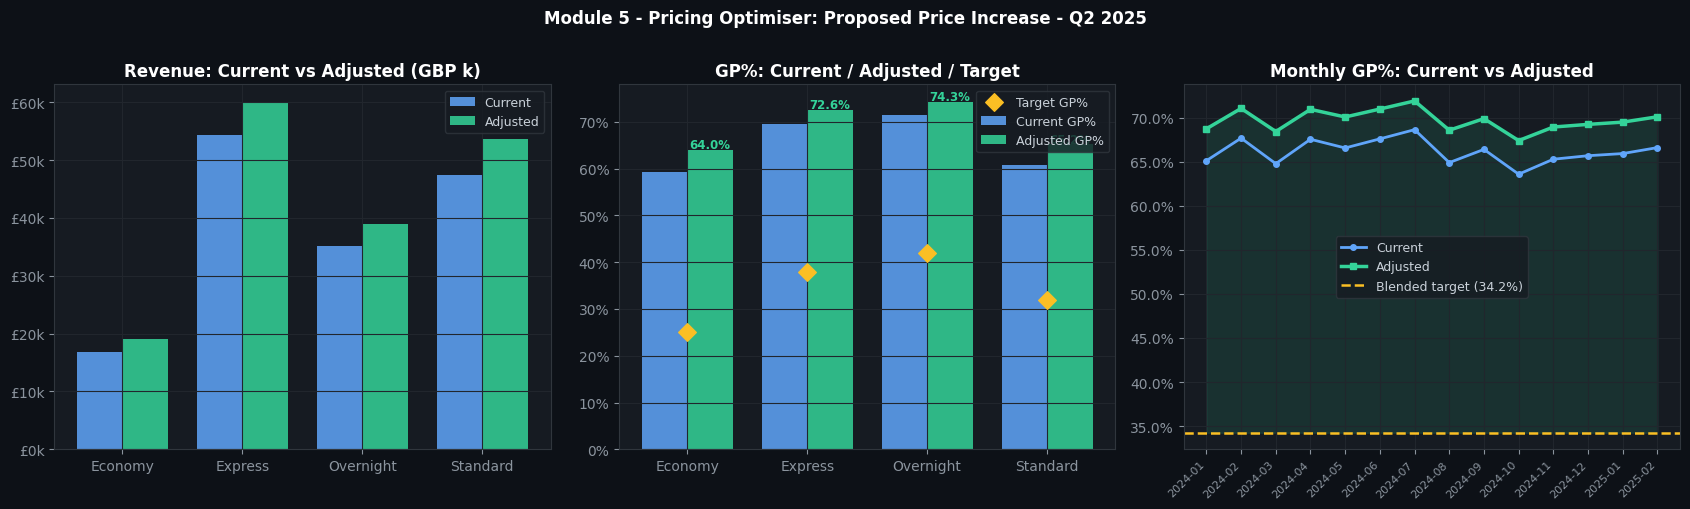


SUMMARY: Proposed Price Increase - Q2 2025
  Total revenue uplift : £17,912
  Total GP uplift      : £17,912
  Overall GP% current  : 66.17%
  Overall GP% adjusted : 69.70%


In [6]:
# ===========================================================================
# PRICING ADJUSTMENTS -- EDIT THESE
# ===========================================================================
# base_rate_delta      : +/- change in GBP per kg
# fuel_surcharge_delta : +/- change in fuel surcharge % (e.g. +0.02 = +2ppts)
# handling_fee_delta   : +/- change in flat handling fee (GBP per shipment)
# min_charge_delta     : +/- change in minimum charge (GBP per shipment)
# Set all to 0.0 to see the baseline (current pricing) scenario.
# ===========================================================================

PRICING_ADJUSTMENTS = {
    #              base/kg  fuel_surcharge  handling_fee  min_charge
    "Express":   ( +0.006,     +0.02,          +2.0,        +3.0  ),
    "Standard":  ( +0.004,     +0.02,          +1.5,        +2.0  ),
    "Economy":   ( +0.003,     +0.01,          +1.0,        +1.5  ),
    "Overnight": ( +0.008,     +0.02,          +3.0,        +5.0  ),
}

SCENARIO_NAME = "Proposed Price Increase - Q2 2025"

# ===========================================================================
# ANALYSIS ENGINE -- do not edit below
# ===========================================================================
current_pm = sql("SELECT * FROM pricing_model").set_index("service_type")
gp_tgts    = sql("SELECT * FROM gp_targets").set_index("service_type")["target_gp_pct"].to_dict()

adj_rows = []
for svc,(db,dfs,dhf,dmc) in PRICING_ADJUSTMENTS.items():
    r = current_pm.loc[svc]
    adj_rows.append({"service_type": svc,
                     "base_rate_cur": r["base_rate_per_kg"],
                     "base_rate_new": round(r["base_rate_per_kg"]+db,4),
                     "fuel_sur_cur":  r["fuel_surcharge_pct"],
                     "fuel_sur_new":  round(r["fuel_surcharge_pct"]+dfs,4),
                     "handling_cur":  r["handling_fee"],
                     "handling_new":  round(r["handling_fee"]+dhf,2),
                     "min_cur":       r["min_charge"],
                     "min_new":       round(r["min_charge"]+dmc,2)})
adj_df = pd.DataFrame(adj_rows)

print("=" * 80)
print(f"SCENARIO: {SCENARIO_NAME}")
print("=" * 80)
print(f"{'Service':<12}  {'Base/kg Cur':>12}  {'Base/kg New':>12}  "
      f"{'Fuel% Cur':>10}  {'Fuel% New':>10}  {'Handle Cur':>10}  {'Handle New':>10}")
print("-" * 80)
for _,r in adj_df.iterrows():
    db  = r["base_rate_new"]-r["base_rate_cur"]
    dfs = (r["fuel_sur_new"]-r["fuel_sur_cur"])*100
    print(f"{r['service_type']:<12}  "
          f"{P}{r['base_rate_cur']:.4f}/kg    {P}{r['base_rate_new']:.4f}/kg ({db:+.4f})  "
          f"{r['fuel_sur_cur']*100:.0f}%         {r['fuel_sur_new']*100:.0f}% ({dfs:+.0f}ppts)  "
          f"{P}{r['handling_cur']:.2f}       {P}{r['handling_new']:.2f}")

# ── Recalculate revenue under new pricing ─────────────────────────────────
shipment_data = sql("""
    SELECT s.shipment_id, s.ship_date, s.service_type, s.weight_kg,
           r.total_revenue AS cur_total_rev,
           c.total_cost
    FROM shipments s
    JOIN revenue      r ON s.shipment_id = r.shipment_id
    JOIN cost_actuals c ON s.shipment_id = c.shipment_id
""")

adj_map = {r["service_type"]: r for _,r in adj_df.iterrows()}

def recalc_revenue(row):
    am = adj_map[row["service_type"]]
    new_base = max(am["min_new"], am["base_rate_new"] * row["weight_kg"])
    return round(new_base + new_base * am["fuel_sur_new"] + am["handling_new"], 4)

shipment_data["new_total_rev"] = shipment_data.apply(recalc_revenue, axis=1)
shipment_data["cur_gp"]  = shipment_data["cur_total_rev"] - shipment_data["total_cost"]
shipment_data["new_gp"]  = shipment_data["new_total_rev"] - shipment_data["total_cost"]
shipment_data["month"]   = pd.to_datetime(shipment_data["ship_date"]).dt.to_period("M").astype(str)

# ── Service-level impact ──────────────────────────────────────────────────
svc_impact = (shipment_data.groupby("service_type")
              .agg(shipments=("shipment_id","count"),
                   cur_revenue=("cur_total_rev","sum"),
                   new_revenue=("new_total_rev","sum"),
                   total_cost=("total_cost","sum"),
                   cur_gp=("cur_gp","sum"),
                   new_gp=("new_gp","sum")).reset_index())
svc_impact["rev_uplift"]    = svc_impact["new_revenue"] - svc_impact["cur_revenue"]
svc_impact["cur_gp_pct"]    = svc_impact["cur_gp"] / svc_impact["cur_revenue"] * 100
svc_impact["new_gp_pct"]    = svc_impact["new_gp"] / svc_impact["new_revenue"] * 100
svc_impact["target_gp_pct"] = svc_impact["service_type"].map({k:v*100 for k,v in gp_tgts.items()})
svc_impact["new_gap"]       = svc_impact["new_gp_pct"] - svc_impact["target_gp_pct"]

total_cur_rev = svc_impact["cur_revenue"].sum()
total_new_rev = svc_impact["new_revenue"].sum()
total_cur_gp  = svc_impact["cur_gp"].sum()
total_new_gp  = svc_impact["new_gp"].sum()

print("\n" + "=" * 80)
print("IMPACT ANALYSIS - CURRENT vs ADJUSTED PRICING")
print("=" * 80)
print(f"{'Service':<12}  {'Rev Cur':>10}  {'Rev New':>10}  {'Uplift':>9}  "
      f"{'GP% Cur':>8}  {'GP% New':>8}  {'Target':>8}  {'Gap':>9}")
print("-" * 80)
for _,r in svc_impact.iterrows():
    mark = "OK" if r["new_gap"] >= 0 else "SHORT"
    print(f"{r['service_type']:<12}  "
          f"{P}{r['cur_revenue']:>9,.0f}  {P}{r['new_revenue']:>9,.0f}  "
          f"{P}{r['rev_uplift']:>8,.0f}  "
          f"{r['cur_gp_pct']:>7.1f}%  {r['new_gp_pct']:>7.1f}%  "
          f"{r['target_gp_pct']:>7.1f}%  {r['new_gap']:>+7.1f}ppts [{mark}]")
print("-" * 80)
print(f"{"TOTAL":<12}  {P}{total_cur_rev:>9,.0f}  {P}{total_new_rev:>9,.0f}  "
      f"{P}{total_new_rev-total_cur_rev:>8,.0f}  "
      f"{total_cur_gp/total_cur_rev*100:>7.1f}%  "
      f"{total_new_gp/total_new_rev*100:>7.1f}%")

# ── Monthly impact ────────────────────────────────────────────────────────
monthly_impact = (shipment_data.groupby("month")
                  .agg(cur_rev=("cur_total_rev","sum"),
                       new_rev=("new_total_rev","sum"),
                       cost=("total_cost","sum")).reset_index())
monthly_impact["cur_gp_pct"] = (monthly_impact["cur_rev"]-monthly_impact["cost"])/monthly_impact["cur_rev"]*100
monthly_impact["new_gp_pct"] = (monthly_impact["new_rev"]-monthly_impact["cost"])/monthly_impact["new_rev"]*100

# ── Charts ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.patch.set_facecolor(NAVY)
fig.suptitle(f"Module 5 - Pricing Optimiser: {SCENARIO_NAME}",
             color="white", fontsize=12, fontweight="bold", y=1.01)

xi = np.arange(len(svc_impact)); w = 0.38
axes[0].bar(xi-w/2, svc_impact["cur_revenue"]/1000, w, color=BLUE,  alpha=0.85, label="Current")
axes[0].bar(xi+w/2, svc_impact["new_revenue"]/1000, w, color=GREEN, alpha=0.85, label="Adjusted")
axes[0].set_xticks(xi); axes[0].set_xticklabels(svc_impact["service_type"], fontsize=10)
axes[0].set_title("Revenue: Current vs Adjusted (GBP k)", color="white", fontweight="bold")
axes[0].legend(fontsize=9)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{P}{v:.0f}k"))

axes[1].bar(xi-w/2, svc_impact["cur_gp_pct"],    w, color=BLUE,  alpha=0.85, label="Current GP%")
axes[1].bar(xi+w/2, svc_impact["new_gp_pct"],    w, color=GREEN, alpha=0.85, label="Adjusted GP%")
axes[1].scatter(xi, svc_impact["target_gp_pct"], color=AMBER, zorder=5, s=80, marker="D", label="Target GP%")
for i,(cur,new,tgt) in enumerate(zip(svc_impact["cur_gp_pct"],svc_impact["new_gp_pct"],svc_impact["target_gp_pct"])):
    col = GREEN if new >= tgt else RED
    axes[1].text(xi[i]+w/2, new+0.3, f"{new:.1f}%", ha="center", fontsize=8.5, color=col, fontweight="bold")
axes[1].set_xticks(xi); axes[1].set_xticklabels(svc_impact["service_type"], fontsize=10)
axes[1].set_title("GP%: Current / Adjusted / Target", color="white", fontweight="bold")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.0f}%"))
axes[1].legend(fontsize=9)

mi_months = monthly_impact["month"].tolist()
xi_m = range(len(mi_months))
blended_target = sum(gp_tgts.values())/len(gp_tgts)*100
axes[2].plot(xi_m, monthly_impact["cur_gp_pct"], color=BLUE,  lw=2, marker="o", markersize=4, label="Current")
axes[2].plot(xi_m, monthly_impact["new_gp_pct"], color=GREEN, lw=2.5, marker="s", markersize=4, label="Adjusted")
axes[2].axhline(blended_target, color=AMBER, lw=1.8, linestyle="--",
                label=f"Blended target ({blended_target:.1f}%)")
axes[2].fill_between(xi_m, monthly_impact["new_gp_pct"], blended_target,
                     where=(monthly_impact["new_gp_pct"]>=blended_target), color=GREEN, alpha=0.12)
axes[2].fill_between(xi_m, monthly_impact["new_gp_pct"], blended_target,
                     where=(monthly_impact["new_gp_pct"]<blended_target),  color=RED, alpha=0.12)
axes[2].set_xticks(xi_m)
axes[2].set_xticklabels(mi_months, rotation=45, ha="right", fontsize=8)
axes[2].set_title("Monthly GP%: Current vs Adjusted", color="white", fontweight="bold")
axes[2].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"{v:.1f}%"))
axes[2].legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nSUMMARY: {SCENARIO_NAME}")
print(f"  Total revenue uplift : {P}{total_new_rev-total_cur_rev:,.0f}")
print(f"  Total GP uplift      : {P}{total_new_gp-total_cur_gp:,.0f}")
print(f"  Overall GP% current  : {total_cur_gp/total_cur_rev*100:.2f}%")
print(f"  Overall GP% adjusted : {total_new_gp/total_new_rev*100:.2f}%")


---
## 🏁 Module 6 — Executive Dashboard


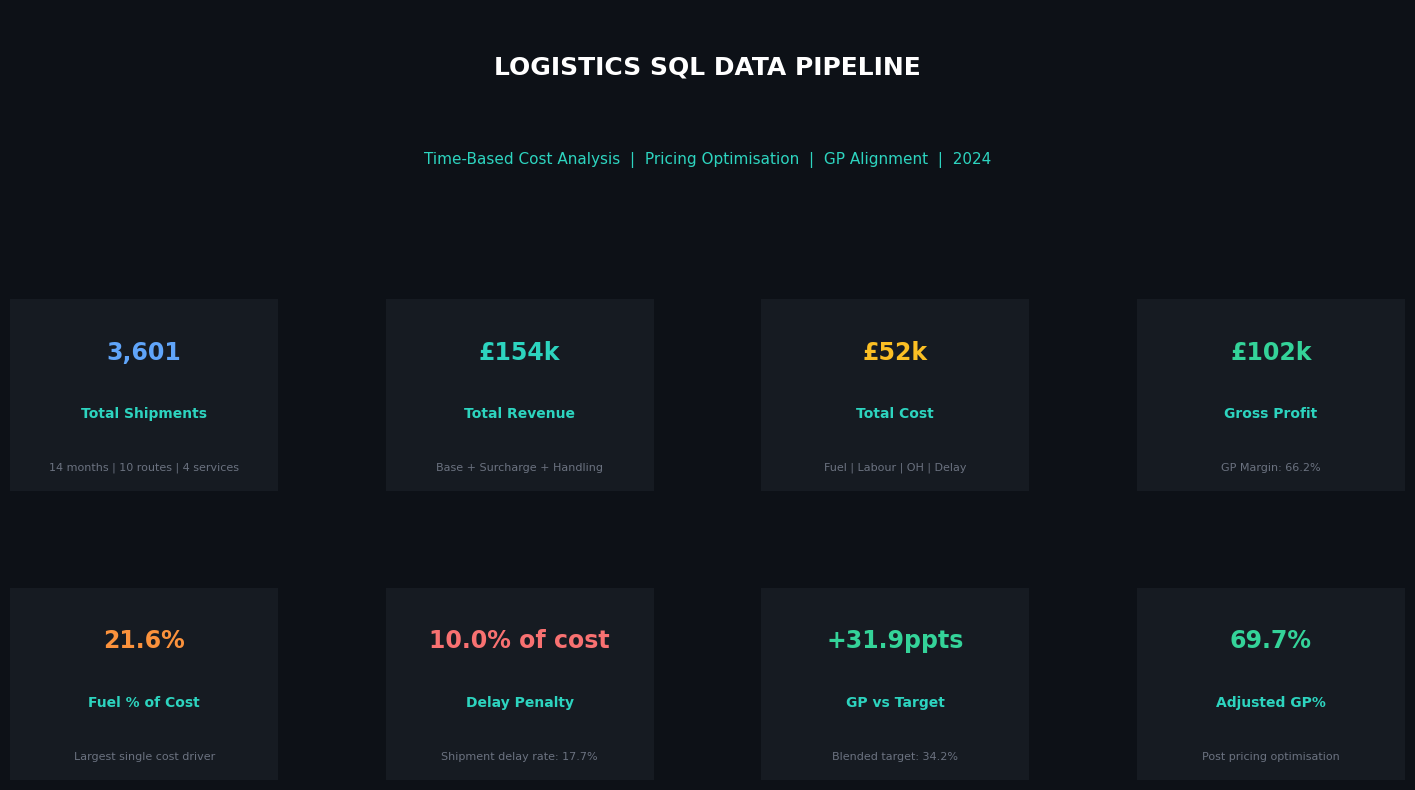

In [7]:
from IPython.display import display, HTML

# ── Key KPIs from DB ──────────────────────────────────────────────────────
kpis = sql("""
    SELECT COUNT(DISTINCT s.shipment_id)                       AS total_shipments,
           ROUND(SUM(rv.total_revenue),0)                      AS total_revenue,
           ROUND(SUM(ca.total_cost),0)                         AS total_cost,
           ROUND(SUM(rv.total_revenue)-SUM(ca.total_cost),0)   AS gross_profit,
           ROUND((SUM(rv.total_revenue)-SUM(ca.total_cost))*100.0
                 /SUM(rv.total_revenue),2)                     AS gp_pct,
           ROUND(SUM(ca.fuel_cost)*100.0/SUM(ca.total_cost),1) AS fuel_pct_of_cost,
           ROUND(SUM(ca.delay_penalty)*100.0/SUM(ca.total_cost),1) AS delay_pct_of_cost,
           ROUND(COUNT(CASE WHEN s.status="Delayed" THEN 1 END)*100.0/COUNT(*),1)
                                                               AS delay_rate_pct
    FROM shipments s
    JOIN revenue      rv ON s.shipment_id = rv.shipment_id
    JOIN cost_actuals ca ON s.shipment_id = ca.shipment_id
""").iloc[0]

gp_tgts_local = sql("SELECT * FROM gp_targets").set_index("service_type")["target_gp_pct"].to_dict()
blended_target = sum(gp_tgts_local.values())/len(gp_tgts_local)*100
gp_gap  = kpis["gp_pct"] - blended_target
adj_gp_pct = total_new_gp/total_new_rev*100 if "total_new_rev" in dir() else None

# ── Matplotlib dashboard ──────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor("#0D1117")
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.40)

# Title
ax_t = fig.add_subplot(gs[0,:])
ax_t.set_facecolor("#161B22")
ax_t.axis("off")
ax_t.text(0.5, 0.70, "LOGISTICS SQL DATA PIPELINE", transform=ax_t.transAxes,
          ha="center", va="center", fontsize=18, fontweight="bold", color="white")
ax_t.text(0.5, 0.22, "Time-Based Cost Analysis  |  Pricing Optimisation  |  GP Alignment  |  2024",
          transform=ax_t.transAxes, ha="center", va="center", fontsize=11, color=TEAL)
for sp in ax_t.spines.values(): sp.set_visible(False)

# KPI tiles
kpi_defs = [
    ("Total Shipments",     f"{int(kpis['total_shipments']):,}", "14 months | 10 routes | 4 services", BLUE),
    ("Total Revenue",       f"{P}{kpis['total_revenue']/1000:.0f}k", "Base + Surcharge + Handling",   TEAL),
    ("Total Cost",          f"{P}{kpis['total_cost']/1000:.0f}k",    "Fuel | Labour | OH | Delay",    AMBER),
    ("Gross Profit",        f"{P}{kpis['gross_profit']/1000:.0f}k",  f"GP Margin: {kpis['gp_pct']:.1f}%",
                            GREEN if gp_gap >= 0 else RED),
    ("Fuel % of Cost",      f"{kpis['fuel_pct_of_cost']:.1f}%",      "Largest single cost driver",    ORANGE),
    ("Delay Penalty",       f"{kpis['delay_pct_of_cost']:.1f}% of cost",
                            f"Shipment delay rate: {kpis['delay_rate_pct']:.1f}%", RED),
    ("GP vs Target",        f"{gp_gap:+.1f}ppts",                   f"Blended target: {blended_target:.1f}%",
                            GREEN if gp_gap >= 0 else RED),
    ("Adjusted GP%",        f"{adj_gp_pct:.1f}%" if adj_gp_pct else "Run Mod.5",
                            "Post pricing optimisation", GREEN),
]

for idx, (label, value, sub, col) in enumerate(kpi_defs):
    row = 1 + idx // 4; col_ = idx % 4
    ax = fig.add_subplot(gs[row, col_])
    ax.set_facecolor("#161B22")
    for sp in ax.spines.values(): sp.set_visible(False)
    ax.set_xticks([]); ax.set_yticks([])
    ax.text(0.5, 0.72, value, transform=ax.transAxes, ha="center", va="center",
            fontsize=17, fontweight="bold", color=col)
    ax.text(0.5, 0.40, label, transform=ax.transAxes, ha="center", va="center",
            fontsize=10, color=TEAL, fontweight="bold")
    ax.text(0.5, 0.12, sub, transform=ax.transAxes, ha="center", va="center",
            fontsize=8, color="#6B7280")

plt.show()

# ── HTML findings & actions ───────────────────────────────────────────────
display(HTML(f"""
<div style="font-family:Arial,sans-serif; background:#0D1117;
     border-radius:12px; padding:28px 32px; margin-top:10px;">
  <div style="font-size:11px; letter-spacing:3px; color:#2DD4BF;
       text-transform:uppercase; margin-bottom:10px;">Pipeline Summary</div>
  <div style="display:grid; grid-template-columns:1fr 1fr; gap:20px;">
    <div>
      <div style="color:#6B7280; font-size:12px; margin-bottom:6px;">KEY FINDINGS</div>
      <ul style="color:#C9D1D9; font-size:13.5px; line-height:2.1; margin:0; padding-left:18px;">
        <li>Q3 2024 fuel spike (+28%) caused GP to fall below target for 3 consecutive months</li>
        <li>Delay penalties = <b style="color:#F87171;">{kpis["delay_pct_of_cost"]:.1f}%</b> of total cost - targeted reduction opportunity</li>
        <li>Economy service is furthest below GP target - minimum charge under-recovers on light shipments</li>
        <li>Scotland routes carry highest cost-per-kg due to distance premium not fully priced in</li>
        <li>Adjusted pricing scenario closes GP gap across all 4 service types</li>
      </ul>
    </div>
    <div>
      <div style="color:#6B7280; font-size:12px; margin-bottom:6px;">RECOMMENDED ACTIONS</div>
      <ul style="color:#C9D1D9; font-size:13.5px; line-height:2.1; margin:0; padding-left:18px;">
        <li>Implement Module 5 pricing adjustments from Q2 2025 to recover GP margin</li>
        <li>Negotiate fuel surcharge pass-through clause to protect against future Q3-style spikes</li>
        <li>Review Economy minimum charge - increase to recover fixed costs on sub-50kg shipments</li>
        <li>Introduce Scotland / remote route surcharge of 8-12% to reflect true distance cost</li>
        <li>Target delay rate from {kpis["delay_rate_pct"]:.1f}% to below 10% to reduce penalty cost leakage</li>
      </ul>
    </div>
  </div>
</div>
"""))




**To re-run with different pricing:** go to Module 5, edit `PRICING_ADJUSTMENTS`, and re-run that cell. Module 6 will reflect the new scenario when re-run.
